In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
users = pd.read_parquet("users.parquet")
movies = pd.read_parquet("movies.parquet")
ratings = pd.read_parquet("ratings.parquet")

In [5]:
print("Users:", users.shape)
print("Movies:", movies.shape)
print("Ratings:", ratings.shape)

ratings.head()

Users: (6040, 5)
Movies: (3883, 3)
Ratings: (1000209, 4)


,UserID,MovieID,Rating,Timestamp
0,1,1193,5,2000-12-31 22:12:40
1,1,661,3,2000-12-31 22:35:09
2,1,914,3,2000-12-31 22:32:48
3,1,3408,4,2000-12-31 22:04:35
4,1,2355,5,2001-01-06 23:38:11


In [6]:
num_users = ratings["UserID"].nunique()
num_movies = ratings["MovieID"].nunique()
num_ratings = len(ratings)

print("Unique users:", num_users)
print("Unique movies:", num_movies)
print("Total ratings:", num_ratings)

Unique users: 6040
Unique movies: 3706
Total ratings: 1000209


In [7]:
matrix_size = num_users * num_movies

sparsity = 1 - (num_ratings / matrix_size)

print("User-Movie matrix size:", matrix_size)
print("Observed ratings:", num_ratings)
print("Sparsity:", sparsity)

User-Movie matrix size: 22384240
Observed ratings: 1000209
Sparsity: 0.9553163743776871


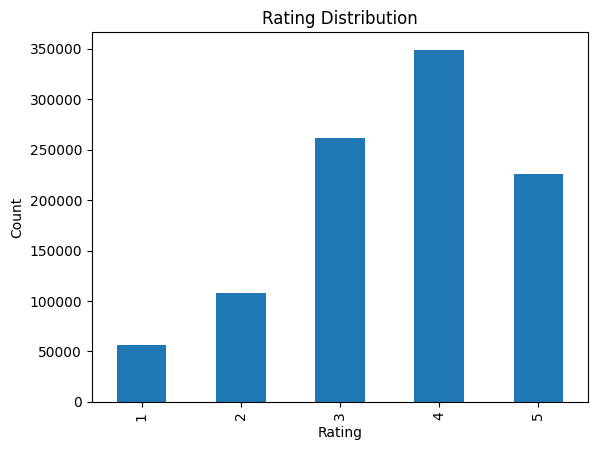

In [8]:
ratings["Rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [9]:
print("Average rating:", ratings["Rating"].mean())

Average rating: 3.581564453029317


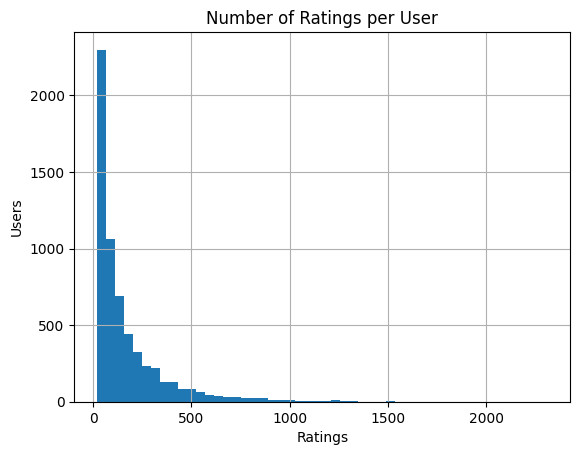

In [10]:
ratings_per_user = ratings.groupby("UserID").size()

ratings_per_user.hist(bins=50)

plt.title("Number of Ratings per User")
plt.xlabel("Ratings")
plt.ylabel("Users")
plt.show()

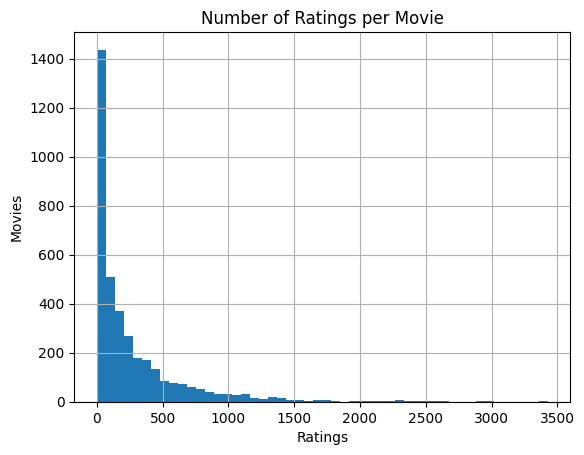

In [11]:
ratings_per_movie = ratings.groupby("MovieID").size()

ratings_per_movie.hist(bins=50)

plt.title("Number of Ratings per Movie")
plt.xlabel("Ratings")
plt.ylabel("Movies")
plt.show()

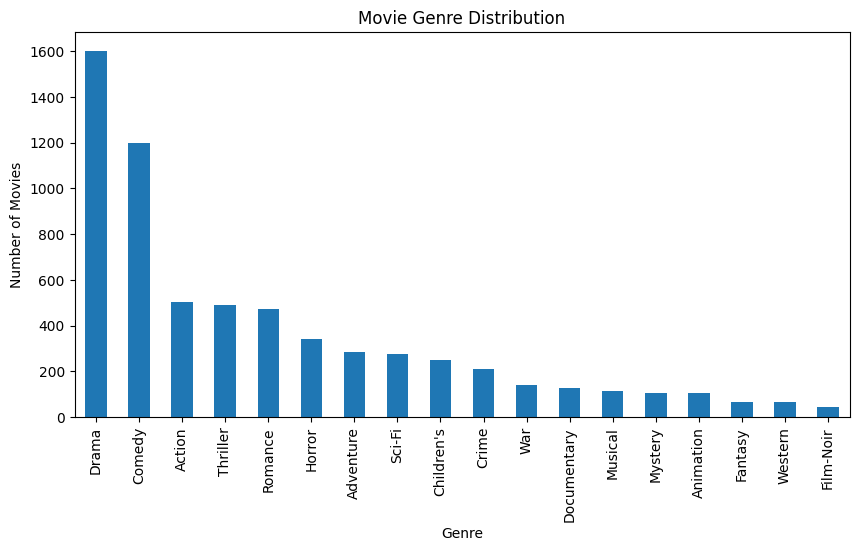

In [12]:
genre_counts = movies["Genres"].explode().value_counts()

genre_counts.plot(kind="bar", figsize=(10,5))

plt.title("Movie Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.show()

In [13]:
# Merge ratings và movies
data = ratings.merge(movies, on="MovieID")

# đảm bảo Genres không bị missing
data = data.dropna(subset=["Genres"])

# split genres
data["Genres"] = data["Genres"].astype(str).str.split("|")

# explode
data = data.explode("Genres").reset_index(drop=True)

# tính rating trung bình
avg_rating_genre = data.groupby("Genres")["Rating"].mean().sort_values(ascending=False)

print(avg_rating_genre)

Genres
['Animation' 'Comedy' 'Thriller']                4.473837
['Sci-Fi' 'War']                                 4.449890
['Animation']                                    4.394336
['Film-Noir' 'Mystery']                          4.367424
['Adventure' 'War']                              4.346107
                                                   ...   
['Action' 'Adventure' "Children's" 'Fantasy']    2.090909
['Comedy' 'Film-Noir' 'Thriller']                2.000000
['Action' 'Adventure' "Children's" 'Sci-Fi']     1.874286
['Action' "Children's"]                          1.742373
['Action' 'Adventure' "Children's"]              1.318182
Name: Rating, Length: 301, dtype: float64


In [14]:
data = ratings.merge(users, on="UserID")

avg_gender_rating = data.groupby("Gender")["Rating"].mean()

print(avg_gender_rating)

Gender
0    3.620366
1    3.568879
Name: Rating, dtype: float64


In [15]:
movie_ratings = data.merge(movies, on="MovieID")

top_movies = movie_ratings.groupby("Title")["Rating"].mean()

top_movies.sort_values(ascending=False).head(10)

Title
Ulysses (Ulisse) (1954)                      5.0
Lured (1947)                                 5.0
Follow the Bitch (1998)                      5.0
Bittersweet Motel (2000)                     5.0
Song of Freedom (1936)                       5.0
One Little Indian (1973)                     5.0
Smashing Time (1967)                         5.0
Schlafes Bruder (Brother of Sleep) (1995)    5.0
Gate of Heavenly Peace, The (1995)           5.0
Baby, The (1973)                             5.0
Name: Rating, dtype: float64

In [16]:
# Save cleaned data for modeling stage

ratings.to_parquet("ratings_clean.parquet", index=False)
movies.to_parquet("movies_clean.parquet", index=False)
users.to_parquet("users_clean.parquet", index=False)

print("Datasets saved successfully.")

Datasets saved successfully.
